In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.thesis_plots import *

In [2]:
# geometrical parameters
L = 1
H = L/5 /2
Htot = H*2
u_wall = 100
mu = 1.716E-5

In [3]:
input_filename = "Volume_CSV/results.csv"

with open(input_filename, 'r') as f:
        ni = int(f.readline().strip().split('=')[1])
        nj = int(f.readline().strip().split('=')[1])
        nk = int(f.readline().strip().split('=')[1])
        
df = pd.read_csv(input_filename, skiprows=3)
data = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}

In [4]:
def compute_ystar(y):
    return (y-H)/H

def compute_analytical_solution(y, dp):
    ystar = compute_ystar(y)
    dpdx = dp / L
    B = - H**2 / mu / u_wall * dpdx
    ustar = 0.5 * (1 + ystar) + 0.5 * B * (1 - ystar**2)
    return ustar
    


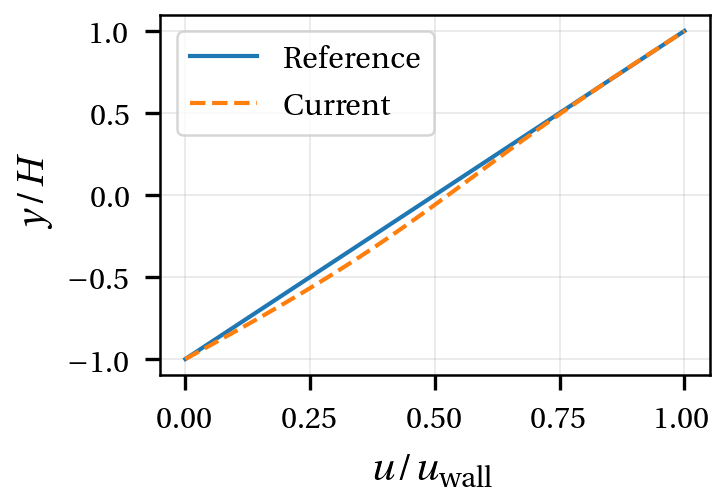

In [5]:
zCheck = 3
u = data['Velocity Z'][zCheck, :, zCheck]
y = data['y'][zCheck, :, zCheck]
ystar = compute_ystar(y)
p = data['Pressure'][zCheck, 30, :]
dp = p[-1] - p[0]
u_analytic = u_wall*y/Htot
u_analytic2 = compute_analytical_solution(y, dp)

set_thesis_style()
fig, ax = create_figure(fraction=0.48, aspect_ratio=1.45, subplots=(1, 1))
ax.plot(u_analytic2, ystar, '-',label='Reference')
ax.plot(data['Velocity Z'][zCheck, :, zCheck]/u_wall, ystar, '--', mfc='none',label='Current')
ax.legend()
ax.set_ylabel(r'$y/H$')
ax.set_xlabel(r'$u/u_{\rm wall}$')
ax.grid(alpha=0.3)
fig.savefig('Pictures/couette_uz.pdf')

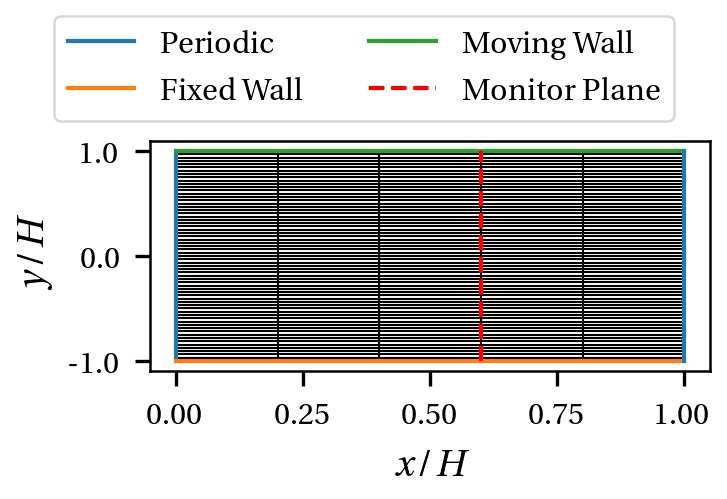

In [6]:
set_thesis_style()
fig, ax = create_figure(fraction=0.48, aspect_ratio=1.45, subplots=(1, 1))

L = data['y'][0, -1, 0]
xComparison = L/2
ni,nj,nk = data['x'].shape
for i in range(1, ni-1):
    ax.plot(data['x'][i, :, 0]/L, data['y'][i, :, 0]/L, 'k', lw=0.5)
for j in range(1, nj-1):
    ax.plot(data['x'][:, j, 0]/L, data['y'][:, j, 0]/L, 'k', lw=0.5)


ax.plot(data['x'][0, :, 0]/L, data['y'][0, :, 0]/L, 'C0', label='Periodic')
ax.plot(data['x'][:, 0, 0]/L, data['y'][:, 0, 0]/L, 'C1', label='Fixed Wall')
ax.plot(data['x'][:, -1, 0]/L, data['y'][:, -1, 0]/L, 'C2', label='Moving Wall')
ax.plot(data['x'][-1, :, 0]/L, data['y'][-1, :, 0]/L, 'C0')
iCheck = np.argmin(np.abs(data['x'][:, 0, 0]-xComparison))
ax.plot(data['x'][iCheck, :, 0]/L, data['y'][-1, :, 0]/L, '--r', label='Monitor Plane')


ax.set_xlabel(r'$x/H$')
ax.set_ylabel(r'$y/H$')
ax.set_yticks([0, 0.5, 1.0], [-1.0, 0.0, 1.0])

# plt.legend(ncol=2, bbox_to_anchor=(0.5, 1.35), loc='upper center')
fig.legend(loc='outside upper center', ncol=2)
plt.savefig('Pictures/couette_grid.pdf')